In [1]:
import pandas as pd 
import numpy as np


In [2]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

In [9]:
df.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [10]:
df.duplicated().sum()

np.int64(1)

In [11]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [12]:
df=df.drop_duplicates()

In [13]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


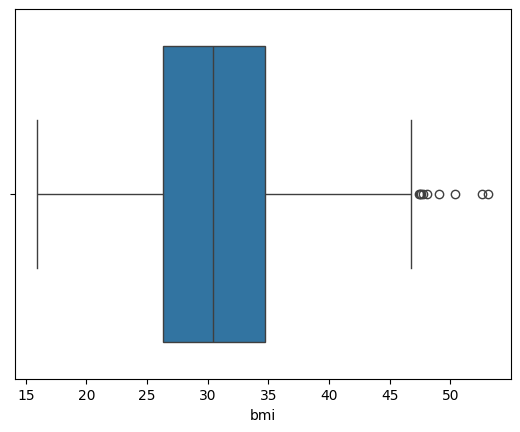

In [16]:
sns.boxplot(x=df["bmi"])
plt.show()

In [17]:
Q1 = df['bmi'].quantile(0.25)

Q3 = df['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df['bmi'] <= lower_limit) |
    (df['bmi'] >= upper_limit)
]
print(f"\nOutliers in {"bmi"}")
print(outliers.shape[0])

# handling outliers 
df["bmi"] = df["bmi"].clip(lower_limit, upper_limit)




Outliers in bmi
9


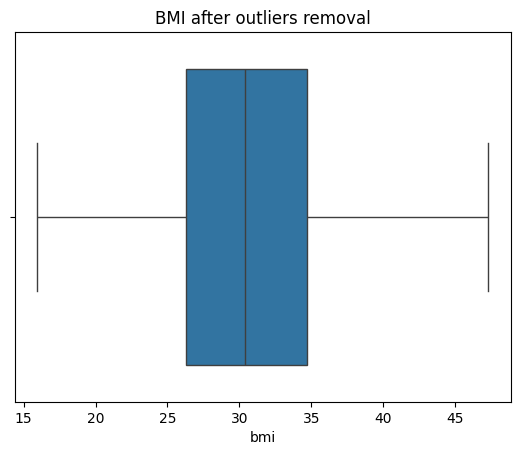

In [18]:
sns.boxplot(x=df["bmi"])
plt.title("BMI after outliers removal")
plt.show()

In [19]:
from sklearn.preprocessing import LabelEncoder

In [20]:
encoder = LabelEncoder()

df['sex'] = encoder.fit_transform(df['sex'])
df['smoker'] = encoder.fit_transform(df['smoker'])
df['region'] = encoder.fit_transform(df['region'])

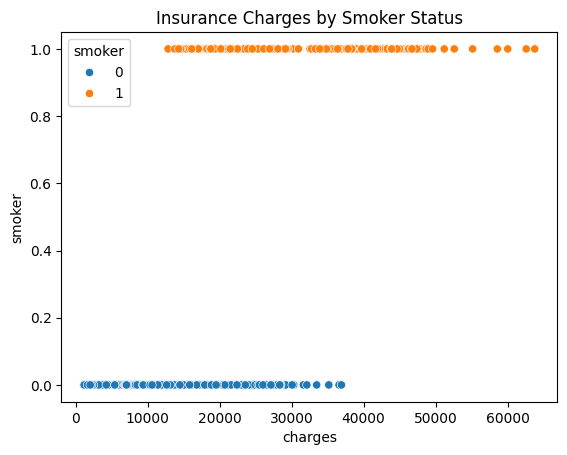

In [21]:
sns.scatterplot(x="charges", y="smoker", hue="smoker", data=df)

plt.title("Insurance Charges by Smoker Status")
plt.show()

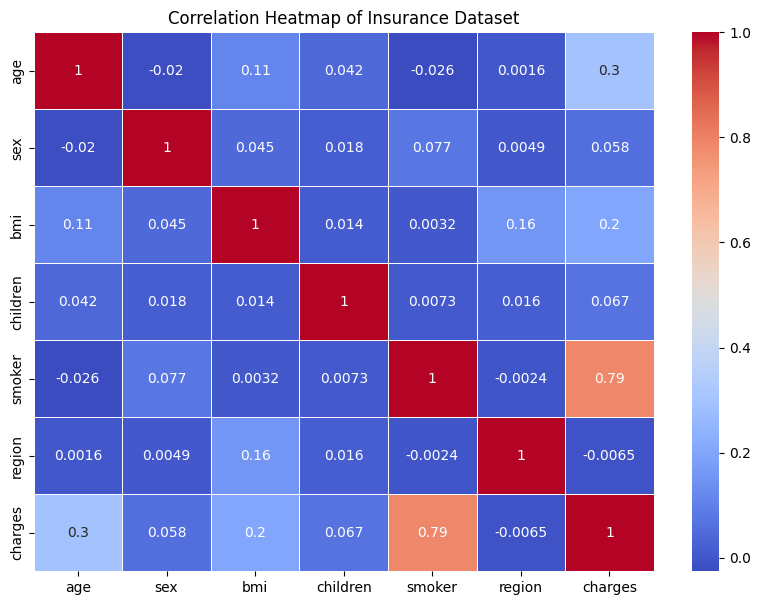

In [22]:
corr = df.corr()

# heatmap
plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Insurance Dataset")
plt.show()

In [23]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830
1334,18,0,31.920,0,0,0,2205.98080
1335,18,0,36.850,0,0,2,1629.83350
1336,21,0,25.800,0,0,3,2007.94500


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [25]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [26]:
X = df[[
    'age',
    'sex',
    'bmi',
    'children',
    'smoker',
    'region'
]]

y = df['charges']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
print("X Train Shape :", X_train.shape)
print("X Test Shape :", X_test.shape)

X Train Shape : (1069, 6)
X Test Shape : (268, 6)


In [29]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [30]:
model = LinearRegression()

In [31]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
y_pred = model.predict(X_test)

In [33]:
y_pred

array([ 8060.27037538,  5576.3293553 , 14389.49802126, 31756.79026787,
        9193.82244506, 13384.7734444 , 30289.27549628,  1297.69284449,
       10864.43283836, 11369.82972701, 10443.42225801, 33152.3881659 ,
       30938.46550793, 17202.99312316, 10663.25257294,  9370.35256123,
        3989.24297205, 31950.45468891,  3073.8104448 ,  5477.59262159,
        3787.7289998 , 30161.10457075, 15110.32265022, 30277.25841792,
       31108.35845681,  5538.55693887, 35698.16608926, 36379.88845151,
       11295.96168047, 14083.15100065,  6384.54458233, 12961.5404216 ,
         673.58117186, 11934.60916593, 39806.11756487, 12157.25477226,
        4573.73212683,  3984.43155071, 31121.62854304,  9211.79599283,
        6910.79340424, 30003.39337257, 34996.63346624, 12180.13177987,
        7424.27896359,  3261.13742861,  6067.73918844,  8812.82673967,
        4313.32314653,  9268.99183569,  6838.96073296, 11939.16859548,
       31121.29300288,  3799.46699502, 10868.21291066,  9989.17149524,
      

In [34]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    recall_score
)

In [35]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)


MAE : 4187.341466330177
MSE : 35467636.638427146
RMSE : 5955.471151674496
R2 Score : 0.8069852180198289


In [36]:
threshold = y.median()

y_test_class = (y_test > threshold).astype(int)
y_pred_class = (y_pred > threshold).astype(int)


In [37]:
accuracy = accuracy_score(y_test_class, y_pred_class)

f1 = f1_score(y_test_class, y_pred_class)

recall = recall_score(y_test_class, y_pred_class)

print("Accuracy :", accuracy)
print("F1 Score :", f1)
print("Recall Score :", recall)


Accuracy : 0.8582089552238806
F1 Score : 0.8671328671328671
Recall Score : 0.9117647058823529


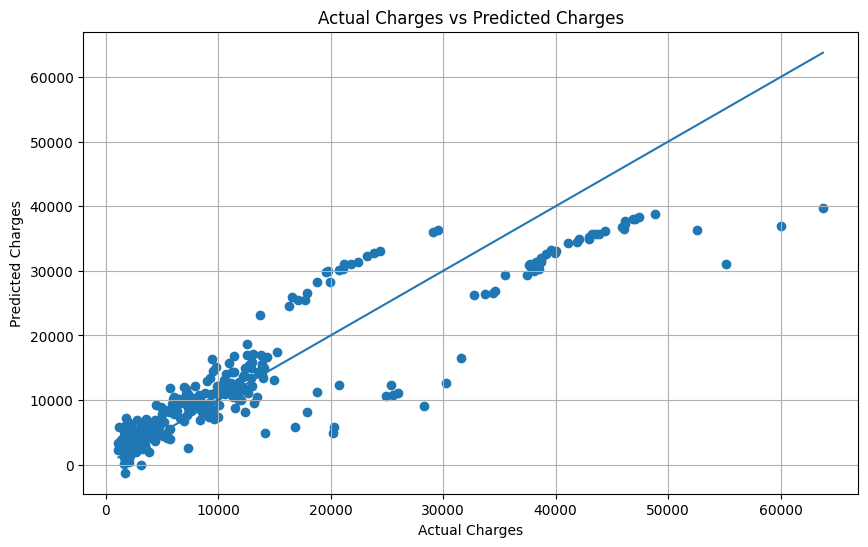

In [38]:
plt.figure(figsize=(10,6))

# Scatter Plot
plt.scatter(y_test, y_pred)

# Labels
plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

# Title
plt.title("Actual Charges vs Predicted Charges")

# Reference Line
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
)

plt.grid()


# Show Plot
plt.show()

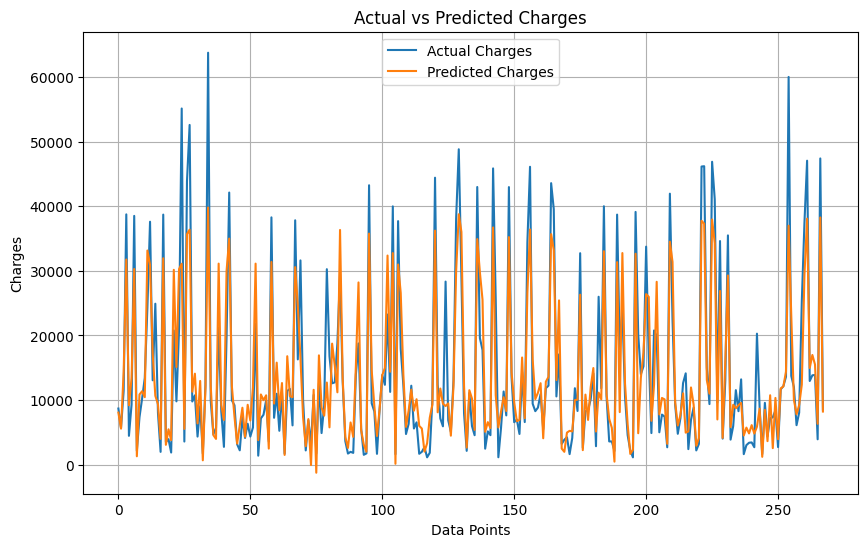

In [39]:
# Create Figure
plt.figure(figsize=(10,6))

# Actual Charges Line
plt.plot(
    y_test.values,
    label="Actual Charges"
)

# Predicted Charges Line
plt.plot(
    y_pred,
    label="Predicted Charges"
)

# Labels
plt.xlabel("Data Points")
plt.ylabel("Charges")

# Title
plt.title("Actual vs Predicted Charges")

# Grid
plt.grid()

# Legend
plt.legend()

# Show Plot
plt.show()

In [40]:
from sklearn.tree import DecisionTreeRegressor

In [41]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [42]:
print("DECISION TREE")

print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("R2 Score:", r2_score(y_test, y_pred_dt))

DECISION TREE
MAE: 2894.432354585821
MSE: 39366527.75753444
R2 Score: 0.7857674631693808


In [43]:
threshold = y.median()

y_test_class = (y_test > threshold).astype(int)
y_pred_dt_class = (y_pred_dt > threshold).astype(int)


In [44]:
accuracy = accuracy_score(y_test_class, y_pred_dt_class)
recall = recall_score(y_test_class, y_pred_dt_class)

print("Accuracy :", accuracy)
print("Recall Score :", recall)


Accuracy : 0.8880597014925373
Recall Score : 0.9044117647058824


In [45]:
from sklearn.model_selection import GridSearchCV


In [46]:
params = {
    "criterion": ["squared_error", "friedman_mse"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"]
}

# Grid Search
grid = GridSearchCV(
    estimator=dt,
    param_grid=params,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

# Train model
grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid.best_params_)

# Best score
print("Best Cross Validation Score:")
print(grid.best_score_)

# Best model
best_dt = grid.best_estimator_

# Prediction
y_pred = best_dt.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Fitting 5 folds for each of 270 candidates, totalling 1350 fits
Best Parameters:
{'criterion': 'squared_error', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Cross Validation Score:
0.8278423535806858
R2 Score: 0.892367145793449
MAE: 2593.359839584189
MSE: 19778189.6505053


In [59]:
threshold = y.median()

y_test_class = (y_test > threshold).astype(int)
y_pred_class = (y_pred > threshold).astype(int)


In [60]:
acc = accuracy_score(y_test_class, y_pred_class)
print("Accuracy after GridSearch:", acc)

Accuracy after GridSearch: 0.9067164179104478


In [ ]:
import pickle

In [65]:
pickle.dump(

    model,

    open("linear_model.pkl", "wb")

)


pickle.dump(

    best_dt,

    open("decision_tree_model.pkl", "wb")

)


print("Models Saved Successfully")


Models Saved Successfully


In [66]:
linear_model = pickle.load(

    open("linear_model.pkl", "rb")

)

decision_tree_model = pickle.load(

    open("decision_tree_model.pkl", "rb")

)

print("Models Loaded Successfully")

Models Loaded Successfully


In [48]:
# from sklearn.ensemble import RandomForestRegressor

In [49]:
# rf = RandomForestRegressor(
#     n_estimators=100,
#     random_state=42
# )

# rf.fit(X_train, y_train)

# y_pred_rf = rf.predict(X_test)

In [50]:
# print("RANDOM FOREST")

# print("MAE:", mean_absolute_error(y_test, y_pred_rf))
# print("MSE:", mean_squared_error(y_test, y_pred_rf))
# print("R2 Score:", r2_score(y_test, y_pred_rf))

In [51]:
# threshold = y.median()

# y_test_class = (y_test > threshold).astype(int)
# y_pred_rf_class = (y_pred_rf > threshold).astype(int)


In [52]:
# accuracy = accuracy_score(y_test_class, y_pred_rf_class)
# recall = recall_score(y_test_class, y_pred_rf_class)

# print("Accuracy :", accuracy)
# print("Recall Score :", recall)


In [53]:
# from sklearn.model_selection import GridSearchCV

In [54]:
# params = {

#     "n_estimators": [50, 100, 200],

#     "max_depth": [5, 10, 15, None],

#     "min_samples_split": [2, 5, 10],

#     "min_samples_leaf": [1, 2, 4],

#     "max_features": ["sqrt", "log2"]

# }


# # Grid Search
# grid = GridSearchCV(

#     estimator=rf,

#     param_grid=params,

#     cv=5,

#     scoring="r2",

#     n_jobs=-1,

#     verbose=1

# )


# # Train Model
# grid.fit(X_train, y_train)


# # Best Model
# rf = grid.best_estimator_


# # Prediction
# y_pred = rf.predict(X_test)


# # Best Parameters
# print("Best Parameters:")

# print(grid.best_params_)

In [55]:
# print("R2 Score:", r2_score(y_test, y_pred))
# print("MAE:", mean_absolute_error(y_test, y_pred))
# print("MSE:", mean_squared_error(y_test, y_pred))

In [56]:
# threshold = y.median()

# y_test_class = (y_test > threshold).astype(int)
# y_pred_class = (y_pred > threshold).astype(int)


In [57]:
# acc = accuracy_score(y_test_class, y_pred_class)
# print("Accuracy after GridSearch:", acc)